<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/08_SVAR_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8 실습 B: 구조적 VAR (SVAR)와 구조적 해석
**Notebook:** `08_SVAR_forecasting.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. reduced-form VAR와 structural VAR(SVAR)의 차이를 이해합니다.
2. 재귀적(recursive) 식별 가정을 바탕으로 A 행렬 제약을 설정합니다.
3. 동일한 다변량 성장률 데이터를 사용하여 SVAR 모형을 적합합니다.
4. 식별된 구조행렬(A matrix)을 해석합니다.
5. 구조적 충격반응함수(IRF)를 통해 충격의 동적 파급 효과를 확인합니다.
6. reduced-form VAR와 SVAR의 예측 관계를 비교합니다.
7. 구조적 제약이 “예측”보다 “해석”에 더 중요한 이유를 이해합니다.

---

## 왜 이 실습이 중요한가?
VAR는 여러 변수의 상호작용을 잘 포착하지만, 잔차 충격이 서로 동시적으로 얽혀 있을 수 있기 때문에  
“어떤 충격이 먼저 발생했고, 어떤 변수가 동시적으로 반응했는가?”를 바로 해석하기 어렵습니다.

SVAR는 경제학적 또는 경영학적 이론을 바탕으로 동시적 관계에 제약을 주어,  
충격의 방향성과 구조를 더 명시적으로 해석할 수 있게 합니다.

이번 실습의 핵심은 **SVAR가 단순히 forecast 점수를 높이기 위한 도구가 아니라, 충격과 정책 효과를 해석하기 위한 구조적 프레임**이라는 점을 이해하는 데 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [2]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 2. 데이터 불러오기와 성장률 변환
SVAR 실습도 VAR 실습과 동일한 거시경제 데이터를 사용합니다.

- `realgdp`
- `realcons`
- `realinv`

를 로그 차분하여 성장률 시계열로 변환합니다.  
이렇게 해야 reduced-form VAR와 SVAR를 같은 데이터 위에서 비교할 수 있습니다.


In [3]:
# ============================================
# 3. Macrodata 로드 및 성장률 변환
# ============================================

import statsmodels.api as sm

macro = sm.datasets.macrodata.load_pandas().data.copy()
dates = pd.date_range(start="1959-03-31", periods=len(macro), freq="QE")

data = pd.DataFrame({
    "gdp_growth": np.log(macro["realgdp"].values),
    "cons_growth": np.log(macro["realcons"].values),
    "inv_growth": np.log(macro["realinv"].values)
}, index=dates)

data = data.diff() * 100
data = data.dropna()

print("Transformed shape:", data.shape)
display(data.head())


Transformed shape: (202, 3)


,gdp_growth,cons_growth,inv_growth
1959-06-30,2.494213,1.528611,8.021268
1959-09-30,-0.119295,1.038598,-7.213104
1959-12-31,0.349453,0.108401,3.442511
1960-03-31,2.219018,0.953415,10.266377
1960-06-30,-0.468455,1.257243,-10.669385


## 3. 학습/테스트 분할
SVAR도 예측 비교를 위해 마지막 8분기를 테스트 구간으로 둡니다.


In [4]:
# ============================================
# 4. Train / Test split
# ============================================

test_size = 8

train = data.iloc[:-test_size]
test = data.iloc[-test_size:]

print("Train length:", len(train))
print("Test length :", len(test))


Train length: 194
Test length : 8


## 4. 먼저 reduced-form VAR의 시차를 선택
SVAR는 보통 reduced-form VAR의 토대 위에서 식별됩니다.  
따라서 먼저 동일한 데이터에 대해 VAR 시차를 선택합니다.


In [5]:
# ============================================
# 5. VAR lag selection
# ============================================

from statsmodels.tsa.vector_ar.var_model import VAR

var_selector = VAR(train)
lag_selection = var_selector.select_order(maxlags=4)

print(lag_selection.summary())
print("Selected orders:", lag_selection.selected_orders)

selected_lag = lag_selection.selected_orders["aic"]
if selected_lag is None:
    selected_lag = 1
selected_lag = int(selected_lag)

print("Selected lag by AIC:", selected_lag)


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -0.1572     -0.1059      0.8546     -0.1364
1    -0.4108*    -0.2057*     0.6631*    -0.3277*
2     -0.3791    -0.02022      0.6845     -0.2337
3     -0.3663      0.1464      0.6935     -0.1586
4     -0.3494      0.3171      0.7055    -0.07944
-------------------------------------------------
Selected orders: {'aic': np.int64(1), 'bic': np.int64(1), 'hqic': np.int64(1), 'fpe': np.int64(1)}
Selected lag by AIC: 1


## 5. Reduced-form VAR 적합
구조적 모형과 비교하기 위해 먼저 일반 VAR를 적합합니다.


In [6]:
# ============================================
# 6. Reduced-form VAR fit
# ============================================

var_results = VAR(train).fit(selected_lag)
print(var_results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 15, Mar, 2026
Time:                     02:11:57
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  -0.170423
Nobs:                     193.000    HQIC:                 -0.291132
Log likelihood:          -773.543    FPE:                   0.688482
AIC:                    -0.373284    Det(Omega_mle):        0.647389
--------------------------------------------------------------------
Results for equation gdp_growth
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.420415         0.095248            4.414           0.000
L1.gdp_growth         -0.347142         0.177217           -1.959           0.050
L1.cons_growth         0.703163         0.136062   

## 6. SVAR 식별을 위한 재귀적 제약 설정
이번 실습에서는 **A-model SVAR**를 사용합니다.

재귀적(Cholesky-style) 식별의 직관은 다음과 같습니다.

- `gdp_growth`는 동시적으로 가장 먼저 움직이는 변수
- `cons_growth`는 같은 시점의 GDP 충격에는 반응할 수 있지만, 투자에는 즉시 반응하지 않음
- `inv_growth`는 같은 시점의 GDP와 소비 충격 모두에 반응할 수 있음

이를 A 행렬의 하삼각(lower triangular) 구조로 표현합니다.


In [7]:
# ============================================
# 7. SVAR 제약행렬(A matrix) 설정
# ============================================
# 1은 대각선 고정값
# 0은 해당 동시효과를 제한
# 'E'는 추정할 파라미터
# ============================================

A = np.array([
    [1,   0,   0],
    ['E', 1,   0],
    ['E', 'E', 1]
], dtype=object)

print("A restriction matrix:")
print(A)


A restriction matrix:
[[1 0 0]
 ['E' 1 0]
 ['E' 'E' 1]]


## 7. SVAR 적합
이제 동일한 학습 데이터와 시차를 사용하여 SVAR를 적합합니다.

> 참고  
> `statsmodels`의 SVAR는 구조 해석에는 유용하지만, 일부 요약 출력 메서드는 버전에 따라 제한이 있을 수 있습니다.  
> 따라서 이번 실습에서는 핵심 결과인 구조행렬, IRF, 그리고 수동 예측 함수를 중심으로 확인합니다.


In [8]:
# ============================================
# 8. SVAR fit
# ============================================

from statsmodels.tsa.vector_ar.svar_model import SVAR

svar_model = SVAR(train, svar_type="A", A=A)
svar_results = svar_model.fit(maxlags=selected_lag)

print("Estimated lag:", svar_results.k_ar)
print("Estimated structural A matrix:")
display(pd.DataFrame(svar_results.A, index=train.columns, columns=train.columns))


Estimated lag: 1
Estimated structural A matrix:


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,gdp_growth,cons_growth,inv_growth
gdp_growth,1.000000,0.000000,0.0
cons_growth,-0.510554,1.000000,0.0
inv_growth,-5.468042,3.073297,1.0


## 8. 구조행렬 해석
추정된 A 행렬의 비대각 원소는 동시적 상호작용의 강도를 의미합니다.  
예를 들어 `cons_growth` 방정식에서 GDP 관련 계수가 유의미하게 나타난다면, 같은 분기 GDP 충격이 소비에 즉시 영향을 줄 수 있음을 시사합니다.

중요한 점은, 이 해석은 어디까지나 **사용자가 부여한 구조적 가정** 위에서만 성립한다는 것입니다.  
즉, SVAR의 힘은 자동 추정에 있는 것이 아니라, **이론과 제약을 연결하는 데** 있습니다.


## 9. Structural IRF 확인
SVAR의 핵심 출력은 종종 예측보다 **구조적 충격반응함수(IRF)** 입니다.  
여기서는 8분기 horizon까지 구조적 IRF를 그려 봅니다.


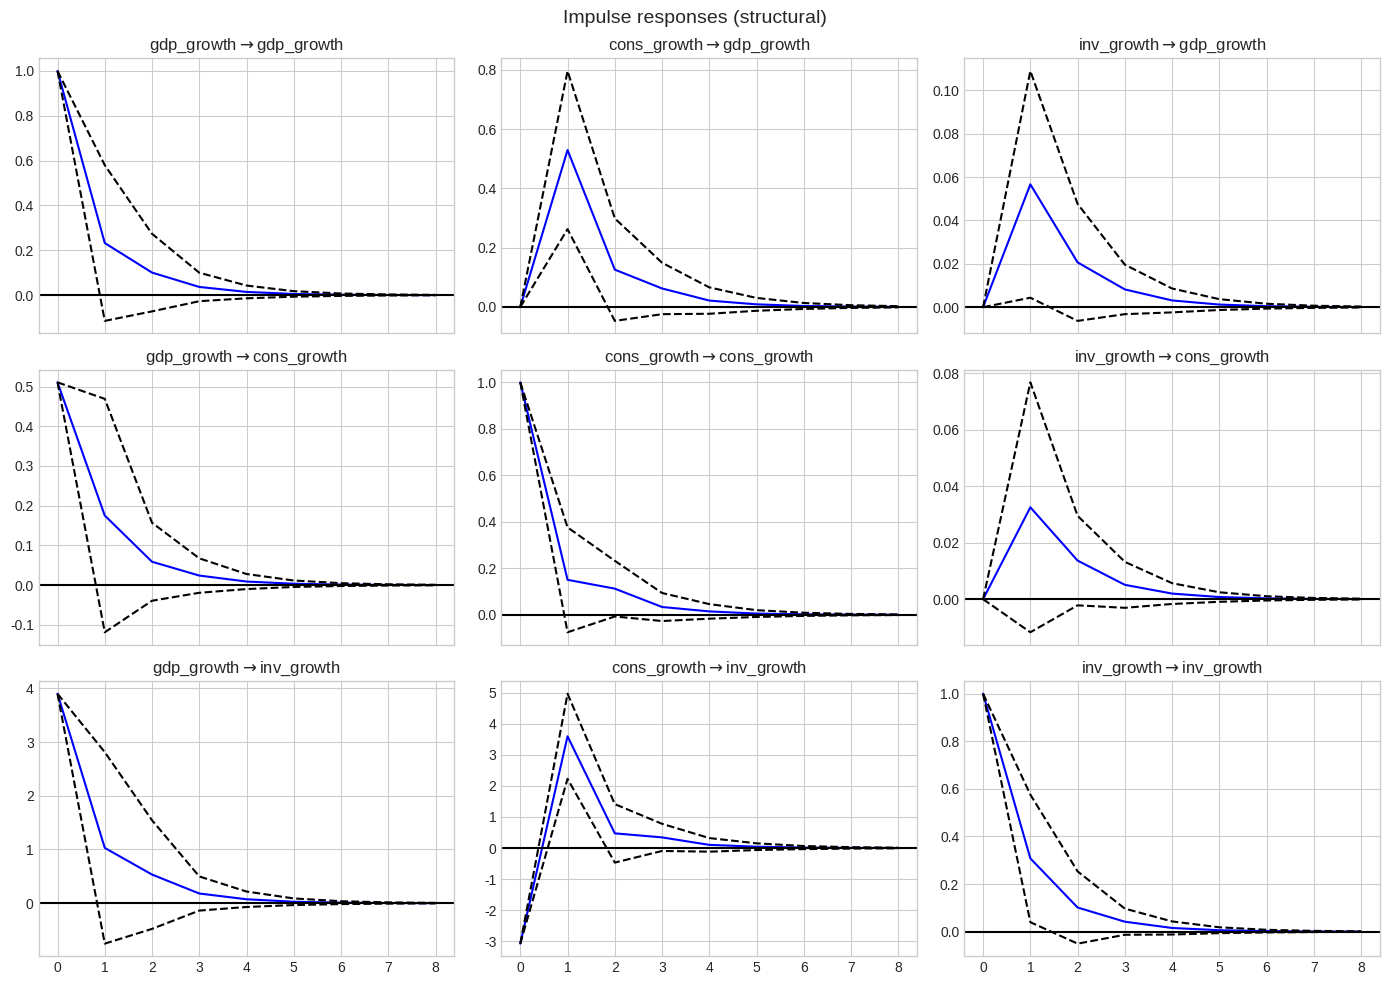

In [9]:
# ============================================
# 9. Structural IRF
# ============================================

irf = svar_results.irf(8)

fig = irf.plot(orth=False)
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


## 10. Reduced-form VAR와 SVAR 예측 비교
중요한 사실 하나를 확인해 보겠습니다.  
같은 데이터와 같은 시차를 사용할 때, SVAR는 구조적 충격의 해석을 바꾸지만 **reduced-form forecast 자체는 VAR와 동일한 경우가 많습니다**.

즉, SVAR의 핵심 가치는 forecast 점수 개선이라기보다 **동시적 충격을 구조적으로 해석하는 데** 있습니다.


In [10]:
# ============================================
# 10. VAR forecast
# ============================================

var_forecast_values = var_results.forecast(train.values[-selected_lag:], steps=len(test))
var_forecast = pd.DataFrame(var_forecast_values, index=test.index, columns=test.columns)

display(var_forecast.head())


,gdp_growth,cons_growth,inv_growth
2007-12-31,0.457964,0.738487,-1.248278
2008-03-31,0.710034,0.791629,0.569048
2008-06-30,0.762796,0.843991,0.742459
2008-09-30,0.791118,0.858551,0.902342
2008-12-31,0.800577,0.865145,0.947195


In [11]:
# ============================================
# 11. SVAR recursive forecast 함수
# ============================================
# statsmodels 버전에 따라 SVARResults.forecast가 내부 속성 문제를 일으킬 수 있으므로,
# 추정된 reduced-form 계수(coefs)와 intercept를 사용해 직접 예측합니다.
# ============================================

def recursive_forecast_from_coefs(coefs, intercept, history, steps):
    history = np.asarray(history, dtype=float)
    p = coefs.shape[0]
    k = history.shape[1]

    if intercept is None:
        intercept = np.zeros(k)
    intercept = np.asarray(intercept, dtype=float)

    values = history.copy()
    forecasts = []

    for _ in range(steps):
        yhat = intercept.copy()
        for i in range(p):
            yhat += coefs[i] @ values[-i-1]
        forecasts.append(yhat.copy())
        values = np.vstack([values, yhat])

    return np.asarray(forecasts)


In [12]:
# ============================================
# 12. SVAR recursive forecast
# ============================================

svar_forecast_values = recursive_forecast_from_coefs(
    coefs=svar_results.coefs,
    intercept=svar_results.intercept,
    history=train.values[-selected_lag:],
    steps=len(test)
)

svar_forecast = pd.DataFrame(
    svar_forecast_values,
    index=test.index,
    columns=test.columns
)

display(svar_forecast.head())


,gdp_growth,cons_growth,inv_growth
2007-12-31,0.457964,0.738487,-1.248278
2008-03-31,0.710034,0.791629,0.569048
2008-06-30,0.762796,0.843991,0.742459
2008-09-30,0.791118,0.858551,0.902342
2008-12-31,0.800577,0.865145,0.947195


In [13]:
# ============================================
# 13. VAR forecast와 SVAR forecast 차이 확인
# ============================================

forecast_diff = (var_forecast - svar_forecast).abs()
display(forecast_diff.head())
print("Maximum absolute difference:", forecast_diff.to_numpy().max())


,gdp_growth,cons_growth,inv_growth
2007-12-31,0.0,0.0,0.0
2008-03-31,0.0,0.0,0.0
2008-06-30,0.0,0.0,0.0
2008-09-30,0.0,0.0,0.0
2008-12-31,0.0,0.0,0.0


Maximum absolute difference: 0.0


## 11. 왜 예측값이 같을 수 있는가?
같은 데이터와 같은 시차를 사용하면, SVAR는 reduced-form VAR의 동학을 바꾸는 것이 아니라  
그 잔차 충격을 **구조적으로 분해하는 방식**을 바꿉니다.

따라서 point forecast는 같거나 거의 같을 수 있습니다.  
이 점은 매우 중요합니다.  
즉, **SVAR는 “더 잘 맞는 예측기”라기보다 “더 잘 해석되는 구조 모형”**에 가깝습니다.


## 12. 예측 성능 비교
그래도 형식적으로는 테스트 구간에 대한 예측 오차를 계산해 볼 수 있습니다.  
또한 Naive baseline과도 비교합니다.


In [14]:
# ============================================
# 14. Naive baseline
# ============================================

naive_forecast = pd.DataFrame(
    np.tile(train.iloc[-1].values, (len(test), 1)),
    index=test.index,
    columns=test.columns
)

display(naive_forecast.head())


,gdp_growth,cons_growth,inv_growth
2007-12-31,0.883185,0.473505,0.197611
2008-03-31,0.883185,0.473505,0.197611
2008-06-30,0.883185,0.473505,0.197611
2008-09-30,0.883185,0.473505,0.197611
2008-12-31,0.883185,0.473505,0.197611


In [15]:
# ============================================
# 15. 평가 함수
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_multivariate(y_true_df, y_pred_df, model_name="Model"):
    rows = []
    for col in y_true_df.columns:
        mae = mean_absolute_error(y_true_df[col], y_pred_df[col])
        rmse = np.sqrt(mean_squared_error(y_true_df[col], y_pred_df[col]))
        rows.append({
            "Model": model_name,
            "Variable": col,
            "MAE": mae,
            "RMSE": rmse
        })
    return pd.DataFrame(rows)


In [16]:
# ============================================
# 16. 성능 비교표
# ============================================

eval_var = evaluate_multivariate(test, var_forecast, "Reduced VAR")
eval_svar = evaluate_multivariate(test, svar_forecast, "SVAR")
eval_naive = evaluate_multivariate(test, naive_forecast, "Naive")

eval_all = pd.concat([eval_var, eval_svar, eval_naive], ignore_index=True)
display(eval_all.sort_values(["Variable", "RMSE"]))


,Model,Variable,MAE,RMSE
7,Naive,cons_growth,0.643788,0.769047
1,Reduced VAR,cons_growth,0.944856,1.076927
4,SVAR,cons_growth,0.944856,1.076927
0,Reduced VAR,gdp_growth,1.073516,1.367190
3,SVAR,gdp_growth,1.073516,1.367190
6,Naive,gdp_growth,1.197483,1.447042
8,Naive,inv_growth,5.362553,7.412552
2,Reduced VAR,inv_growth,5.574006,7.843179
5,SVAR,inv_growth,5.574006,7.843179


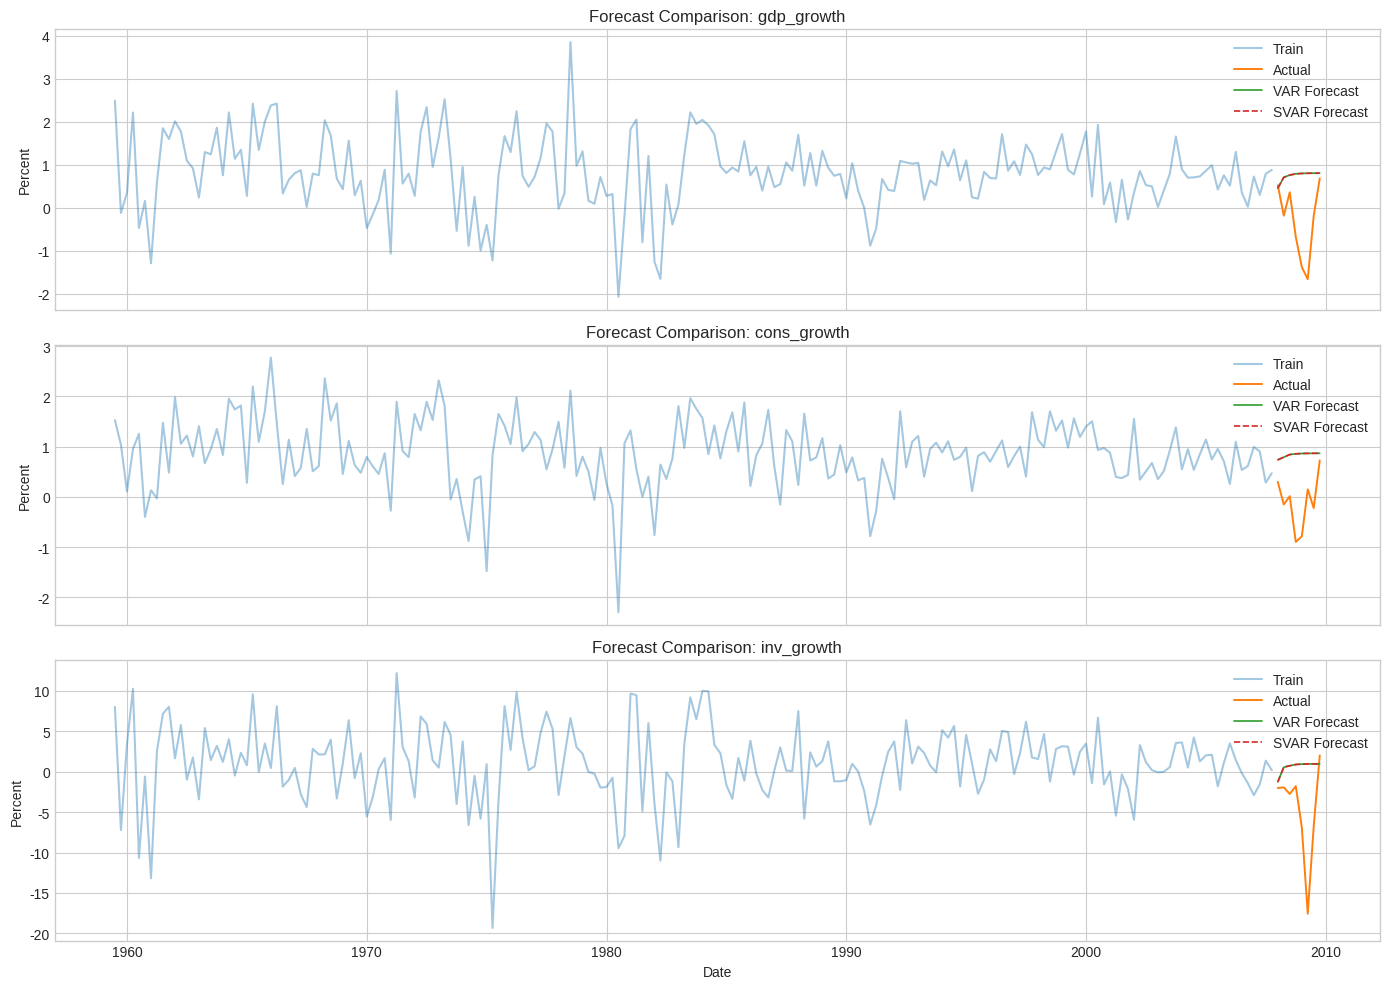

In [17]:
# ============================================
# 17. 변수별 실제값 vs 예측값
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, col in enumerate(test.columns):
    axes[i].plot(train.index, train[col], label="Train", alpha=0.4)
    axes[i].plot(test.index, test[col], label="Actual", linewidth=1.4)
    axes[i].plot(var_forecast.index, var_forecast[col], label="VAR Forecast", linewidth=1.2)
    axes[i].plot(svar_forecast.index, svar_forecast[col], label="SVAR Forecast", linewidth=1.2, linestyle="--")
    axes[i].set_title(f"Forecast Comparison: {col}")
    axes[i].set_ylabel("Percent")
    axes[i].legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 13. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- SVAR는 reduced-form VAR에 구조적 제약을 부여한 모형이다.
- 재귀적 식별은 변수의 동시적 반응 순서를 가정한다.
- 구조행렬(A matrix)은 경제학적 또는 경영학적 이론을 반영하는 핵심 장치이다.
- SVAR의 가장 중요한 산출물은 종종 예측값보다 구조적 IRF와 충격 해석이다.
- 같은 동학과 시차를 사용하면 VAR와 SVAR의 point forecast는 같거나 매우 비슷할 수 있다.
- 따라서 SVAR의 실질적 가치는 “forecast score 개선”보다 “구조적 해석 가능성”에 있다.


## 14. 연습문제 (Exercises)

1. 변수 순서를 바꾸어 A 행렬을 다시 정의한 뒤, 구조행렬과 IRF가 어떻게 달라지는지 비교하시오.

2. `gdp_growth`, `cons_growth`, `inv_growth` 대신 다른 2~3개 거시 변수를 사용하여 새로운 SVAR 시스템을 구성하시오.

3. 왜 SVAR의 point forecast가 reduced-form VAR forecast와 같거나 매우 비슷할 수 있는지 설명하시오.

4. 재귀적 식별(Cholesky ordering)의 장점과 한계를 논의하시오.

5. 정책 분석이나 충격 해석이 목적일 때, 왜 일반 VAR보다 SVAR가 더 유용할 수 있는지 설명하시오.
